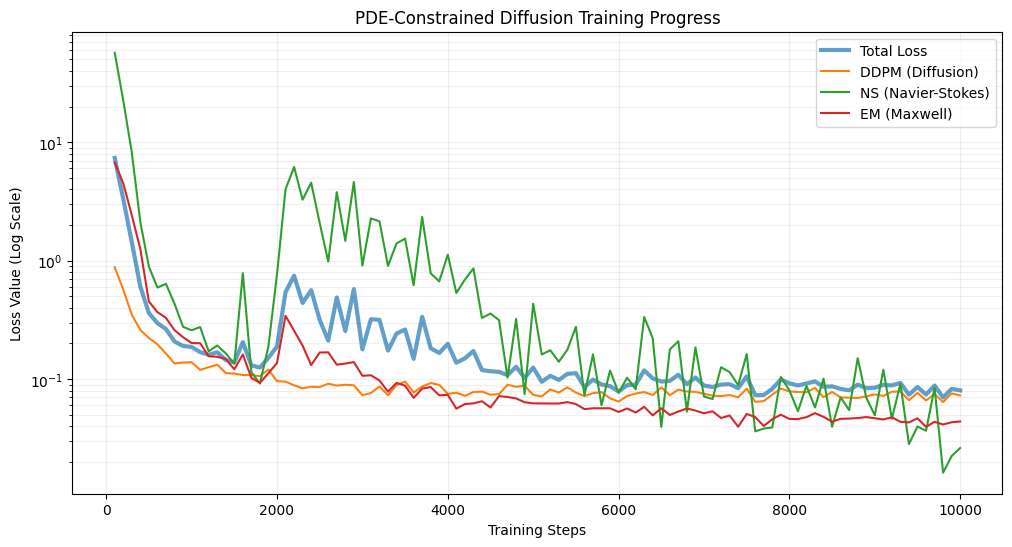

In [1]:
import matplotlib.pyplot as plt
import re
import pandas as pd

# 1. Your raw data string
log_data = """
[   100/10000]  loss=7.3676  ddpm=0.8783  ns=56.9510  em=6.7198  div=2.44453
[   200/10000]  loss=3.3084  ddpm=0.5684  ns=22.4489  em=4.4987  div=0.90525
[   300/10000]  loss=1.4302  ddpm=0.3498  ns=8.1881  em=2.4180  div=0.39459
[   400/10000]  loss=0.6033  ddpm=0.2597  ns=2.1115  em=1.2488  div=0.14971
[   500/10000]  loss=0.3610  ddpm=0.2222  ns=0.8895  em=0.4517  div=0.09232
[   600/10000]  loss=0.2970  ddpm=0.1968  ns=0.5922  em=0.3676  div=0.08251
[   700/10000]  loss=0.2645  ddpm=0.1640  ns=0.6375  em=0.3287  div=0.07640
[   800/10000]  loss=0.2076  ddpm=0.1355  ns=0.4329  em=0.2590  div=0.05914
[   900/10000]  loss=0.1905  ddpm=0.1380  ns=0.2763  em=0.2258  div=0.04573
[  1000/10000]  loss=0.1870  ddpm=0.1389  ns=0.2584  em=0.2015  div=0.04200
[  1100/10000]  loss=0.1691  ddpm=0.1196  ns=0.2751  em=0.2008  div=0.03831
[  1200/10000]  loss=0.1603  ddpm=0.1261  ns=0.1714  em=0.1558  div=0.03106
[  1300/10000]  loss=0.1685  ddpm=0.1324  ns=0.1923  em=0.1541  div=0.02842
[  1400/10000]  loss=0.1451  ddpm=0.1125  ns=0.1649  em=0.1480  div=0.02733
[  1500/10000]  loss=0.1381  ddpm=0.1113  ns=0.1349  em=0.1210  div=0.02359
[  1600/10000]  loss=0.2052  ddpm=0.1082  ns=0.7849  em=0.1616  div=0.04731
[  1700/10000]  loss=0.1306  ddpm=0.1081  ns=0.1145  em=0.1025  div=0.01714
[  1800/10000]  loss=0.1251  ddpm=0.1059  ns=0.0917  em=0.0929  div=0.01473
[  1900/10000]  loss=0.1515  ddpm=0.1204  ns=0.1895  em=0.1121  div=0.01774
[  2000/10000]  loss=0.1883  ddpm=0.0960  ns=0.7656  em=0.1368  div=0.04150
[  2100/10000]  loss=0.5408  ddpm=0.0952  ns=4.0041  em=0.3420  div=0.21823
[  2200/10000]  loss=0.7464  ddpm=0.0887  ns=6.1826  em=0.2566  div=0.27372
[  2300/10000]  loss=0.4390  ddpm=0.0836  ns=3.2681  em=0.1913  div=0.18907
[  2400/10000]  loss=0.5632  ddpm=0.0862  ns=4.5520  em=0.1313  div=0.17267
[  2500/10000]  loss=0.3165  ddpm=0.0857  ns=2.0821  em=0.1676  div=0.11566
[  2600/10000]  loss=0.2111  ddpm=0.0914  ns=0.9820  em=0.1683  div=0.09299
[  2700/10000]  loss=0.4890  ddpm=0.0882  ns=3.7848  em=0.1323  div=0.18127
[  2800/10000]  loss=0.2544  ddpm=0.0895  ns=1.4665  em=0.1353  div=0.09382
[  2900/10000]  loss=0.5748  ddpm=0.0887  ns=4.6234  em=0.1392  div=0.19732
[  3000/10000]  loss=0.1783  ddpm=0.0730  ns=0.9085  em=0.1067  div=0.07710
[  3100/10000]  loss=0.3200  ddpm=0.0763  ns=2.2750  em=0.1077  div=0.10967
[  3200/10000]  loss=0.3164  ddpm=0.0867  ns=2.1476  em=0.0973  div=0.10337
[  3300/10000]  loss=0.1742  ddpm=0.0730  ns=0.9027  em=0.0784  div=0.06244
[  3400/10000]  loss=0.2426  ddpm=0.0891  ns=1.3980  em=0.0929  div=0.08852
[  3500/10000]  loss=0.2620  ddpm=0.0952  ns=1.5349  em=0.0880  div=0.08869
[  3600/10000]  loss=0.1482  ddpm=0.0772  ns=0.6190  em=0.0694  div=0.04412
[  3700/10000]  loss=0.3353  ddpm=0.0865  ns=2.3410  em=0.0832  div=0.12746
[  3800/10000]  loss=0.1822  ddpm=0.0926  ns=0.7814  em=0.0856  div=0.05714
[  3900/10000]  loss=0.1660  ddpm=0.0894  ns=0.6690  em=0.0729  div=0.04854
[  4000/10000]  loss=0.1986  ddpm=0.0751  ns=1.1241  em=0.0736  div=0.07375
[  4100/10000]  loss=0.1375  ddpm=0.0768  ns=0.5338  em=0.0563  div=0.03475
[  4200/10000]  loss=0.1496  ddpm=0.0722  ns=0.6908  em=0.0615  div=0.04401
[  4300/10000]  loss=0.1728  ddpm=0.0778  ns=0.8600  em=0.0624  div=0.05511
[  4400/10000]  loss=0.1192  ddpm=0.0784  ns=0.3286  em=0.0650  div=0.02990
[  4500/10000]  loss=0.1165  ddpm=0.0738  ns=0.3578  em=0.0576  div=0.02512
[  4600/10000]  loss=0.1151  ddpm=0.0747  ns=0.3143  em=0.0718  div=0.03581
[  4700/10000]  loss=0.1080  ddpm=0.0896  ns=0.1029  em=0.0706  div=0.02155
[  4800/10000]  loss=0.1270  ddpm=0.0861  ns=0.3223  em=0.0687  div=0.03523
[  4900/10000]  loss=0.1024  ddpm=0.0878  ns=0.0745  em=0.0637  div=0.01578
[  5000/10000]  loss=0.1250  ddpm=0.0735  ns=0.4326  em=0.0624  div=0.03888
[  5100/10000]  loss=0.0948  ddpm=0.0714  ns=0.1614  em=0.0623  div=0.01939
[  5200/10000]  loss=0.1067  ddpm=0.0818  ns=0.1752  em=0.0622  div=0.02394
[  5300/10000]  loss=0.0983  ddpm=0.0770  ns=0.1401  em=0.0622  div=0.02214
[  5400/10000]  loss=0.1107  ddpm=0.0852  ns=0.1769  em=0.0639  div=0.02739
[  5500/10000]  loss=0.1122  ddpm=0.0769  ns=0.2759  em=0.0615  div=0.03166
[  5600/10000]  loss=0.0856  ddpm=0.0720  ns=0.0727  em=0.0558  div=0.01403
[  5700/10000]  loss=0.0990  ddpm=0.0760  ns=0.1618  em=0.0567  div=0.02314
[  5800/10000]  loss=0.0902  ddpm=0.0777  ns=0.0603  em=0.0567  div=0.01562
[  5900/10000]  loss=0.0872  ddpm=0.0688  ns=0.1180  em=0.0567  div=0.01982
[  6000/10000]  loss=0.0785  ddpm=0.0646  ns=0.0767  em=0.0528  div=0.01915
[  6100/10000]  loss=0.0889  ddpm=0.0719  ns=0.1028  em=0.0565  div=0.02119
[  6200/10000]  loss=0.0897  ddpm=0.0755  ns=0.0821  em=0.0522  div=0.01563
[  6300/10000]  loss=0.1184  ddpm=0.0778  ns=0.3344  em=0.0583  div=0.02536
[  6400/10000]  loss=0.1014  ddpm=0.0734  ns=0.2211  em=0.0494  div=0.01937
[  6500/10000]  loss=0.0952  ddpm=0.0851  ns=0.0395  em=0.0567  div=0.01045
[  6600/10000]  loss=0.0968  ddpm=0.0731  ns=0.1780  em=0.0498  div=0.01714
[  6700/10000]  loss=0.1088  ddpm=0.0814  ns=0.2086  em=0.0533  div=0.02317
[  6800/10000]  loss=0.0904  ddpm=0.0786  ns=0.0532  em=0.0565  div=0.01531
[  6900/10000]  loss=0.1031  ddpm=0.0780  ns=0.1853  em=0.0542  div=0.02358
[  7000/10000]  loss=0.0882  ddpm=0.0751  ns=0.0713  em=0.0514  div=0.01490
[  7100/10000]  loss=0.0857  ddpm=0.0725  ns=0.0679  em=0.0535  div=0.02113
[  7200/10000]  loss=0.0899  ddpm=0.0718  ns=0.1260  em=0.0469  div=0.01723
[  7300/10000]  loss=0.0906  ddpm=0.0734  ns=0.1145  em=0.0493  div=0.01649
[  7400/10000]  loss=0.0838  ddpm=0.0702  ns=0.0888  em=0.0396  div=0.01333
[  7500/10000]  loss=0.1053  ddpm=0.0831  ns=0.1627  em=0.0508  div=0.01617
[  7600/10000]  loss=0.0731  ddpm=0.0642  ns=0.0362  em=0.0477  div=0.01154
[  7700/10000]  loss=0.0734  ddpm=0.0652  ns=0.0382  em=0.0402  div=0.00729
[  7800/10000]  loss=0.0829  ddpm=0.0739  ns=0.0391  em=0.0459  div=0.00901
[  7900/10000]  loss=0.0993  ddpm=0.0831  ns=0.1042  em=0.0500  div=0.01409
[  8000/10000]  loss=0.0921  ddpm=0.0787  ns=0.0803  em=0.0461  div=0.01501
[  8100/10000]  loss=0.0884  ddpm=0.0778  ns=0.0536  em=0.0460  div=0.01305
[  8200/10000]  loss=0.0920  ddpm=0.0775  ns=0.0877  em=0.0477  div=0.01863
[  8300/10000]  loss=0.0956  ddpm=0.0842  ns=0.0576  em=0.0516  div=0.01050
[  8400/10000]  loss=0.0861  ddpm=0.0703  ns=0.1009  em=0.0480  div=0.01792
[  8500/10000]  loss=0.0868  ddpm=0.0780  ns=0.0396  em=0.0437  div=0.00929
[  8600/10000]  loss=0.0826  ddpm=0.0700  ns=0.0701  em=0.0462  div=0.02005
[  8700/10000]  loss=0.0804  ddpm=0.0696  ns=0.0547  em=0.0464  div=0.01286
[  8800/10000]  loss=0.0898  ddpm=0.0692  ns=0.1501  em=0.0469  div=0.01868
[  8900/10000]  loss=0.0838  ddpm=0.0715  ns=0.0698  em=0.0478  div=0.01007
[  9000/10000]  loss=0.0845  ddpm=0.0743  ns=0.0495  em=0.0467  div=0.01244
[  9100/10000]  loss=0.0894  ddpm=0.0721  ns=0.1200  em=0.0456  div=0.01604
[  9200/10000]  loss=0.0884  ddpm=0.0782  ns=0.0463  em=0.0476  div=0.01477
[  9300/10000]  loss=0.0929  ddpm=0.0787  ns=0.0912  em=0.0436  div=0.01446
[  9400/10000]  loss=0.0739  ddpm=0.0663  ns=0.0283  em=0.0431  div=0.01016
[  9500/10000]  loss=0.0858  ddpm=0.0766  ns=0.0398  em=0.0467  div=0.01197
[  9600/10000]  loss=0.0741  ddpm=0.0660  ns=0.0366  em=0.0395  div=0.00986
[  9700/10000]  loss=0.0883  ddpm=0.0746  ns=0.0847  em=0.0436  div=0.01829
[  9800/10000]  loss=0.0700  ddpm=0.0640  ns=0.0162  em=0.0414  div=0.00594
[  9900/10000]  loss=0.0827  ddpm=0.0757  ns=0.0224  em=0.0432  div=0.00866
[ 10000/10000]  loss=0.0803  ddpm=0.0728  ns=0.0262  em=0.0439  div=0.00918"""

# 2. Parse the data using Regex
pattern = r"\[\s*(\d+)/\d+\]\s+loss=([\d\.]+)\s+ddpm=([\d\.]+)\s+ns=([\d\.]+)\s+em=([\d\.]+)\s+div=([\d\.]+)"
matches = re.findall(pattern, log_data)

# 3. Create a DataFrame
df = pd.DataFrame(matches, columns=['step', 'loss', 'ddpm', 'ns', 'em', 'div'])
df = df.astype(float)

# 4. Plotting
plt.figure(figsize=(12, 6))

# Plot the total loss and individual components
plt.plot(df['step'], df['loss'], label='Total Loss', linewidth=3, alpha=0.7)
plt.plot(df['step'], df['ddpm'], label='DDPM (Diffusion)')
plt.plot(df['step'], df['ns'], label='NS (Navier-Stokes)')
plt.plot(df['step'], df['em'], label='EM (Maxwell)')

plt.yscale('log') # Use log scale because NS loss starts very high
plt.xlabel('Training Steps')
plt.ylabel('Loss Value (Log Scale)')
plt.title('PDE-Constrained Diffusion Training Progress')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()